Importing Libraries & Defining Functions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler,RobustScaler,MaxAbsScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay,roc_curve)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
results = []

def evaluate_model(name, y_test, y_pred, y_prob):
    print("\n" + "="*4 + f"{name} Results" + "="*4)
    print(f"Accuracy Score:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall Score:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score:        {f1_score(y_test, y_pred):.4f}")
    print(f"ROC_AUC Score:   {roc_auc_score(y_test, y_prob):.4f}")

    print("\n" + "="*4 + "Classification Report" + "="*4)
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    # store results
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

Reading the dataset

In [3]:
data=pd.read_csv("Telco-Customer-Churn.csv")

In [4]:
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
shape=data.shape
print(f'The shape of the dataset {shape}.\nThe file has {shape[0]} number of rows and {shape[1]} number of columns.')

The shape of the dataset (7043, 21).
The file has 7043 number of rows and 21 number of columns.


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
data["Contract"].describe()

count               7043
unique                 3
top       Month-to-month
freq                3875
Name: Contract, dtype: object

In [9]:
data["Churn"].info

<bound method Series.info of 0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object>

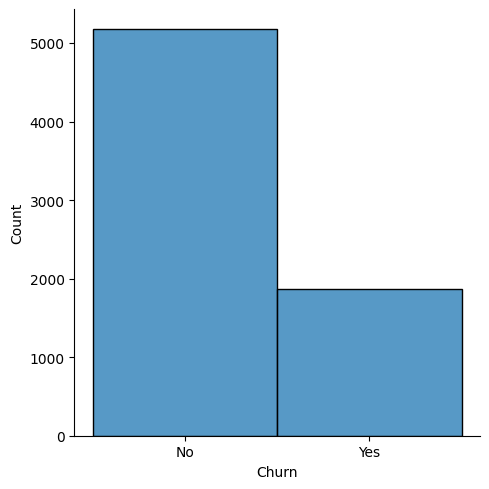

In [10]:
sb.displot(data["Churn"])

In [11]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
data.duplicated().sum()

np.int64(0)

Dropping columns which doesn't affect the results

In [13]:
df=data.drop("customerID",axis=1)
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Fix TotalCharges — it's a string, must do this before any analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the few nulls it creates
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert target to 0/1 for correlation analysis
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [15]:
df["TotalCharges"].head(5)

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [16]:
df["TotalCharges"].describe()

count    7043.000000
mean     2281.916928
std      2265.270398
min        18.800000
25%       402.225000
50%      1397.475000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [17]:
df["TotalCharges"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype  
--------------  -----  
7043 non-null   float64
dtypes: float64(1)
memory usage: 55.2 KB


In [18]:
df=df.dropna()

In [19]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

EDA Analysis

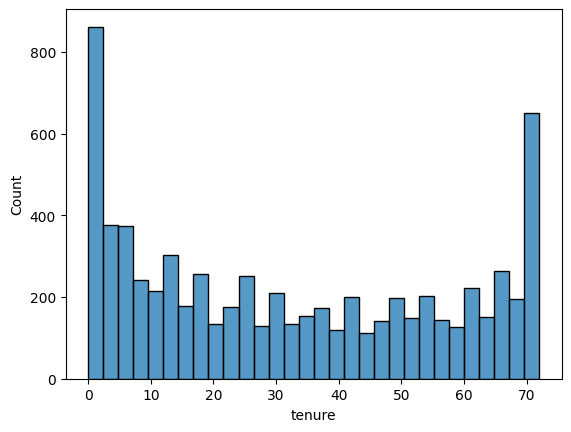

In [20]:
#distribution
sb.histplot(df["tenure"],bins=30)
plt.show()


<Axes: ylabel='MonthlyCharges'>

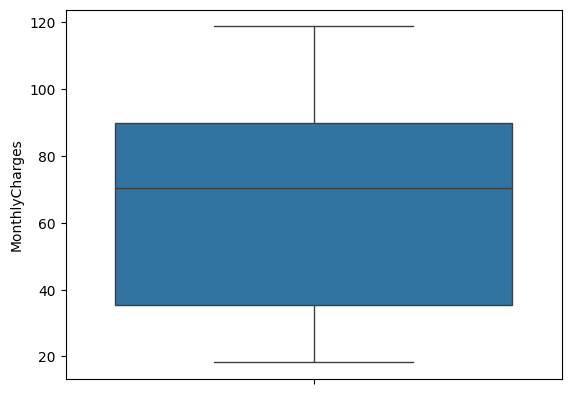

In [21]:
#boxplot
sb.boxplot(df["MonthlyCharges"])

<Axes: xlabel='Contract', ylabel='count'>

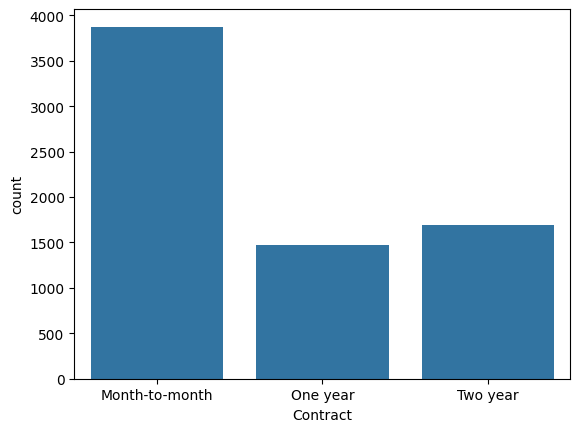

In [22]:
# count of each category
df['Contract'].value_counts()
# bar chart
sb.countplot(x='Contract', data=df)

In [23]:
categorical_data=df.select_dtypes(include="object").columns.tolist()
numerical_data=df.select_dtypes(include="number").columns.tolist()
numerical_data.remove("Churn")
print(categorical_data)
print(numerical_data)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


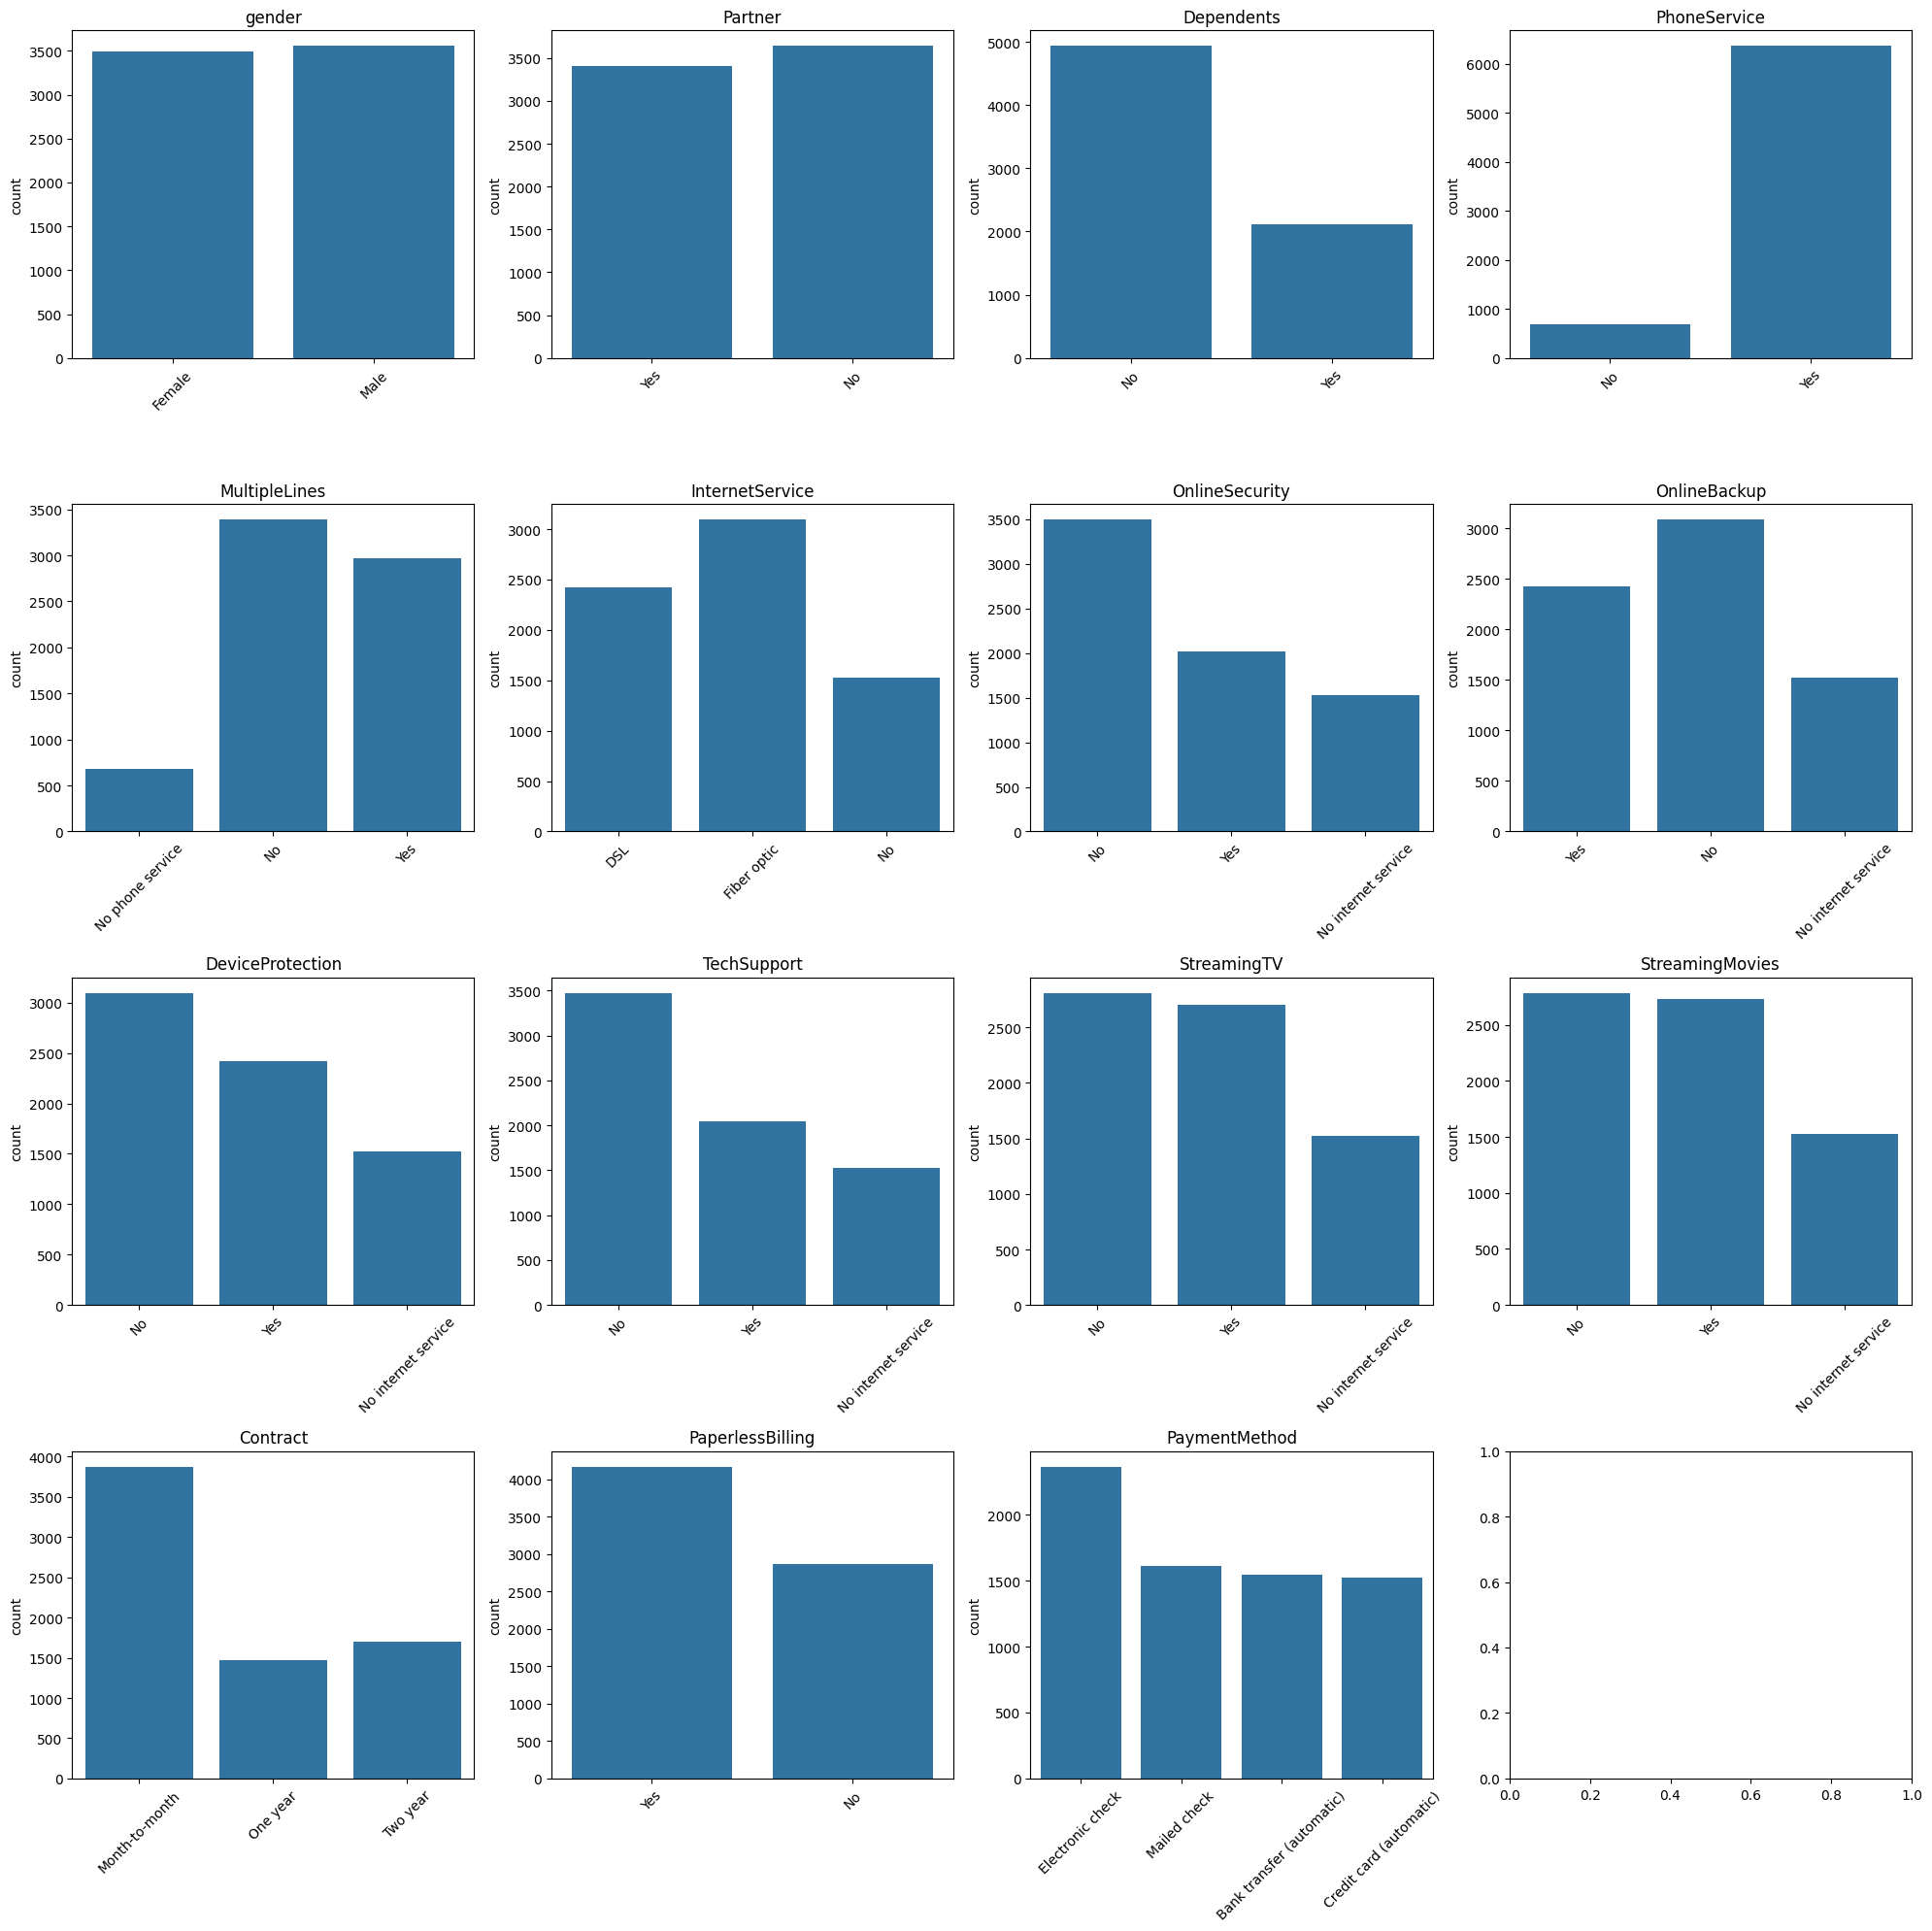

In [24]:
#plotting categorical_data
fig, axes=plt.subplots(nrows=4, ncols=4, figsize=(20,20))
axes=axes.flatten()
for i, col in enumerate(categorical_data):
    sb.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis="x",rotation=45)
plt.tight_layout()
plt.show()

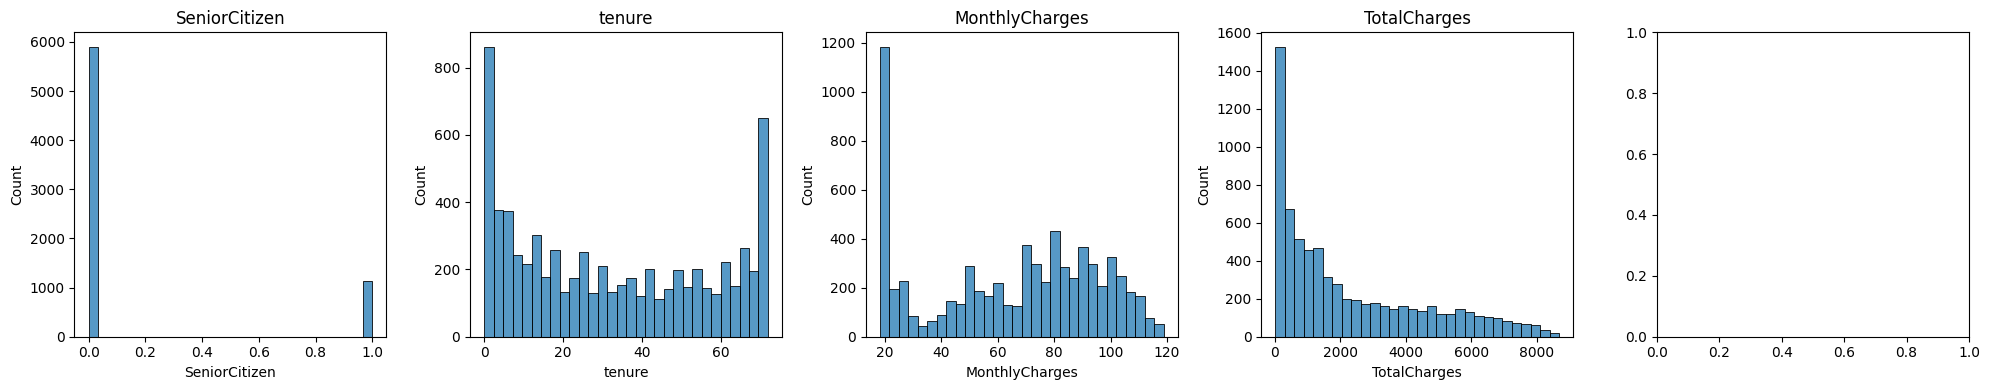

In [25]:
#plotting numerical_data
fig, axes= plt.subplots(nrows=1,ncols=5,figsize=(20,4))

for i, col in enumerate(numerical_data):
    sb.histplot(df[col],bins=30,ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

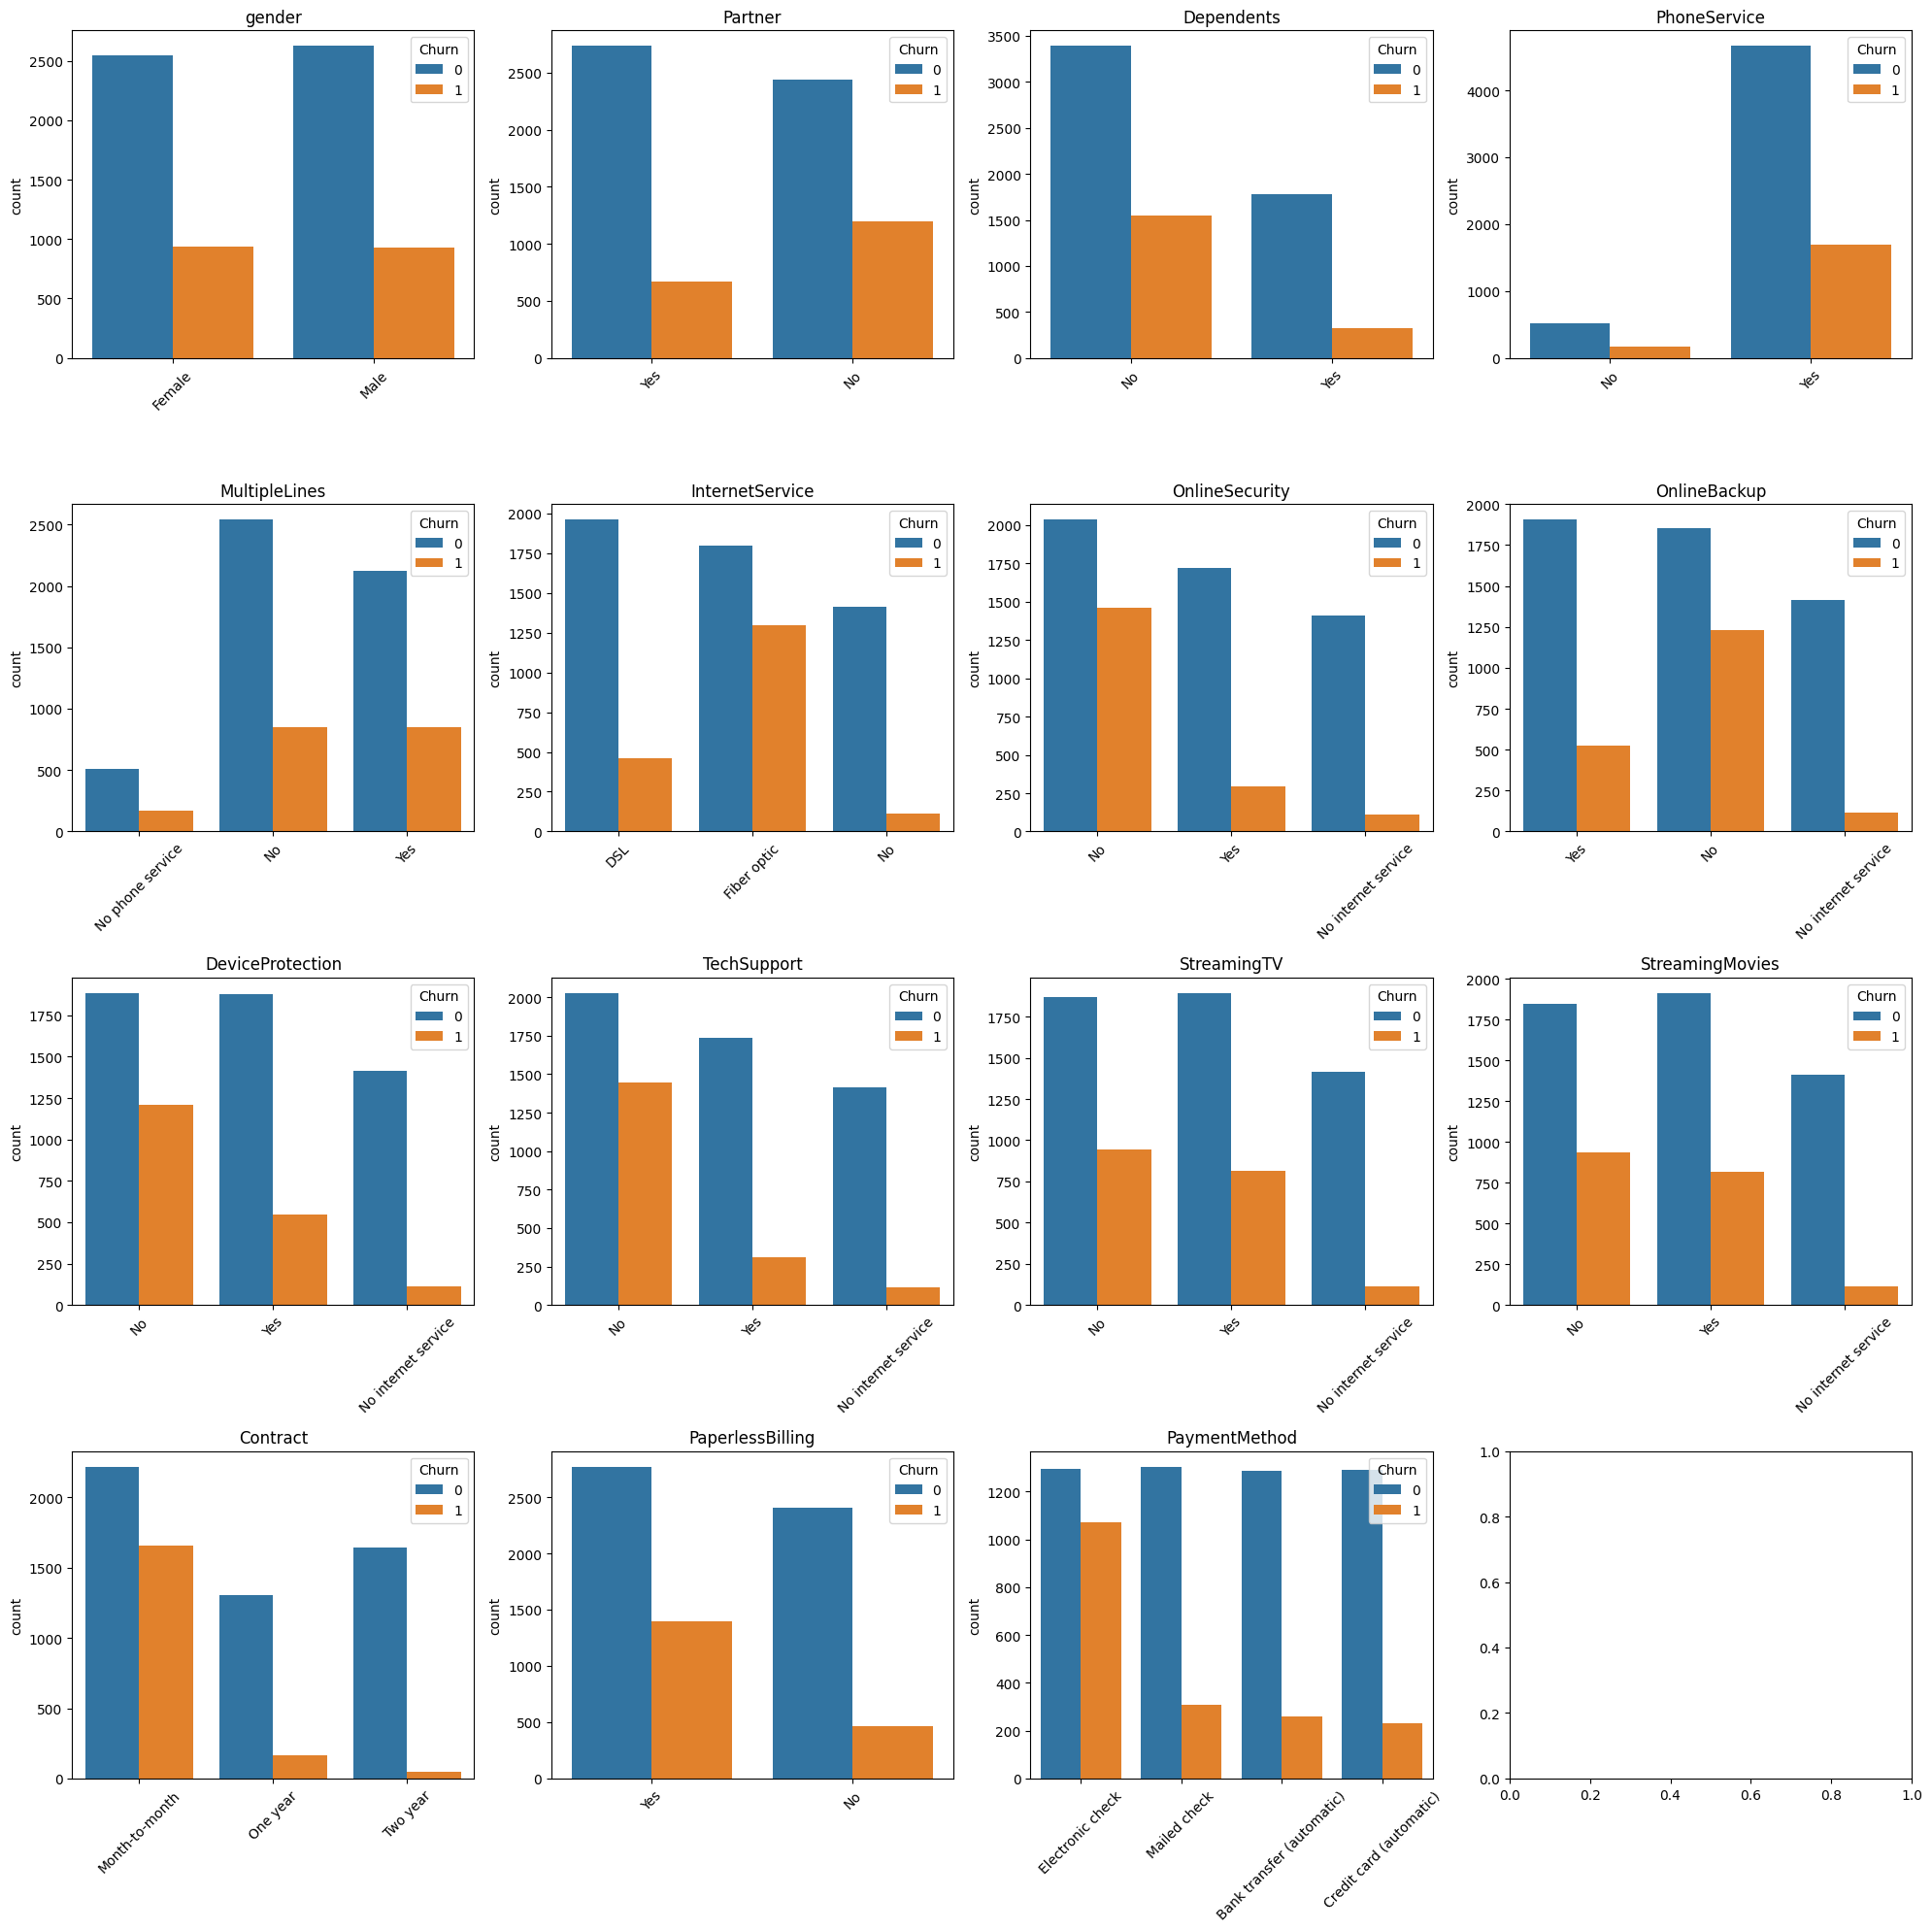

In [26]:
#relationship between categorical_data and churn
fig, axes=plt.subplots(nrows=4, ncols=4, figsize=(20,20))
axes=axes.flatten()
for i, col in enumerate(categorical_data):
    sb.countplot(x=df[col],hue=df["Churn"], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis="x",rotation=45)
plt.tight_layout()
plt.show()

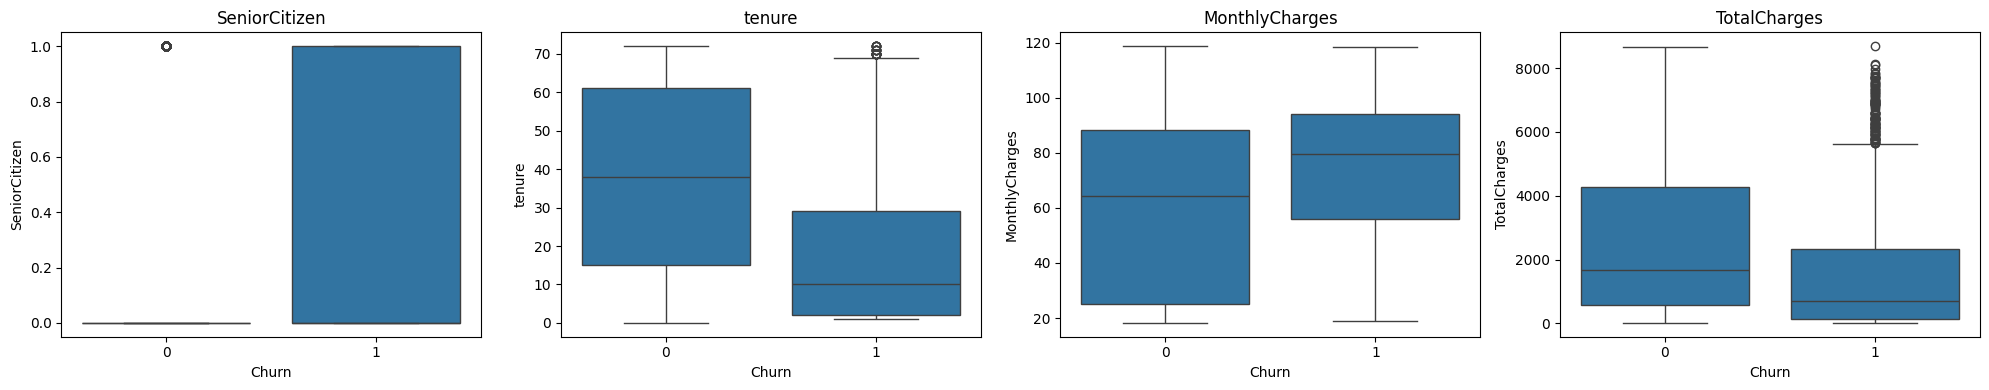

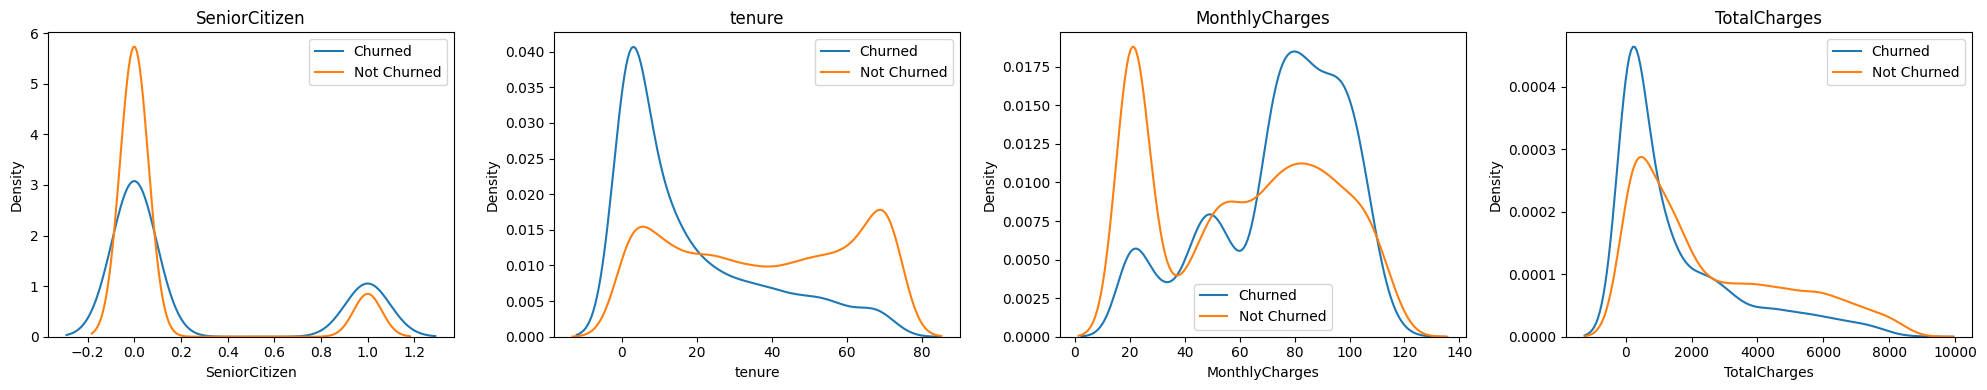

In [27]:
#relationship between numerical_data and churn
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_data), figsize=(5*len(numerical_data), 4))

for i, col in enumerate(numerical_data):
    sb.boxplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=1, ncols=len(numerical_data), figsize=(5*len(numerical_data), 4))

for i,col in enumerate(numerical_data):
    sb.kdeplot(df[df['Churn']==1][col], label='Churned', ax=axes[i])
    sb.kdeplot(df[df['Churn']==0][col], label='Not Churned', ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [28]:
#churn rate calculation
churn_rate=df["Churn"].value_counts(normalize=True)*100
print(churn_rate)

for col in categorical_data:
    print(df.groupby(col)["Churn"].mean()*100)
    print()

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64
gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64

Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64

Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64

PhoneService
No     24.926686
Yes    26.709637
Name: Churn, dtype: float64

MultipleLines
No                  25.044248
No phone service    24.926686
Yes                 28.609896
Name: Churn, dtype: float64

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn, dtype: float64

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64

OnlineBackup
No                     39.928756
No internet service     7.404980
Yes                    21.531494
Name: Churn, dtype: float64

DeviceProtection
No                     39.127625
No internet service     7.404980
Yes           

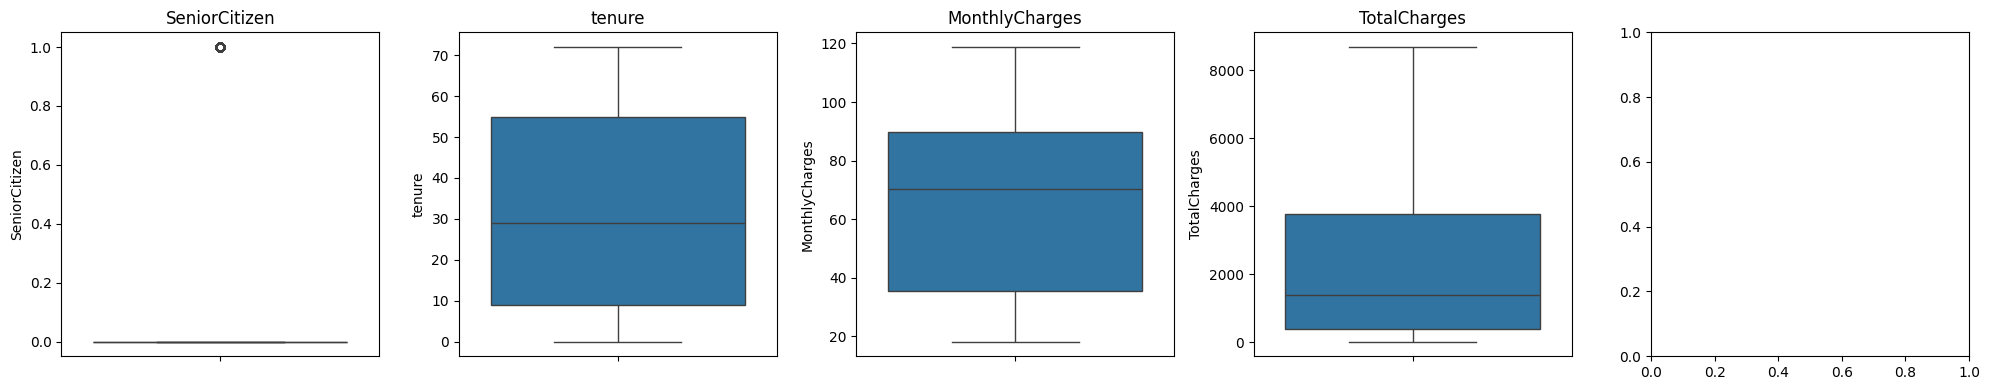

In [29]:
#boxplotting numerical_data
fig, axes= plt.subplots(nrows=1,ncols=5,figsize=(20,4))

for i, col in enumerate(numerical_data):
    sb.boxplot(df[col],ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [30]:
#outlier detection
for col in numerical_data:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) |
                  (df[col] > q3 + 1.5*iqr)]
    print(f"{col} — Outliers found: {len(outliers)}")

SeniorCitizen — Outliers found: 1142
tenure — Outliers found: 0
MonthlyCharges — Outliers found: 0
TotalCharges — Outliers found: 0


Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


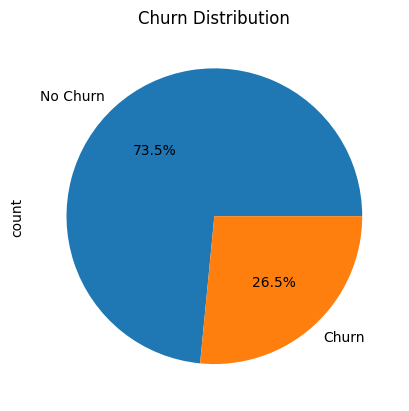

In [31]:
#class imbalance check
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                labels=['No Churn', 'Churn'])
plt.title('Churn Distribution')
plt.show()

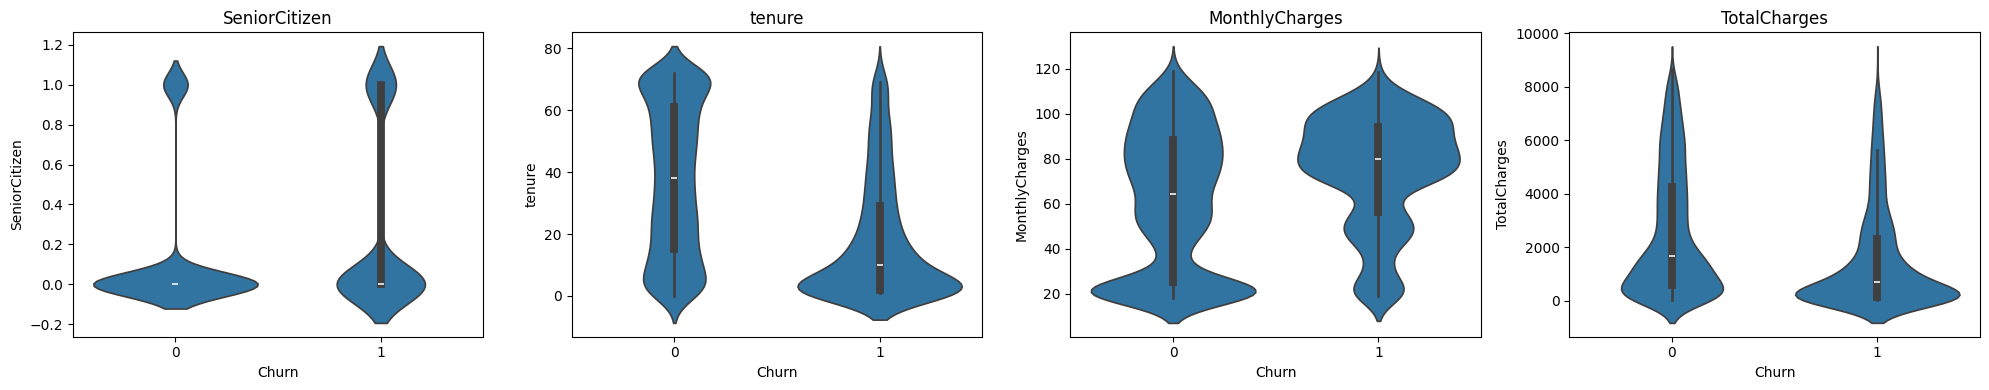

In [32]:
#violin plots
fig, axes= plt.subplots(nrows=1,ncols=len(numerical_data),figsize=(5*len(numerical_data),4))

for i, col in enumerate(numerical_data):
    sb.violinplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

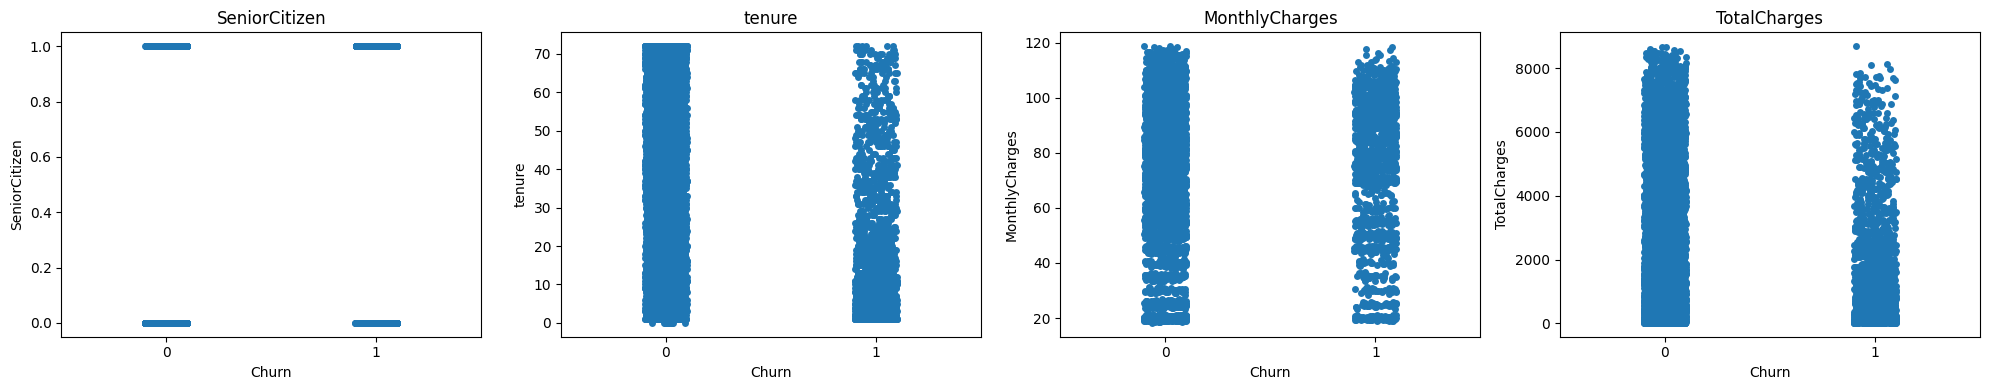

In [33]:
#strip plot
fig, axes= plt.subplots(nrows=1,ncols=len(numerical_data),figsize=(5*len(numerical_data),4))

for i, col in enumerate(numerical_data):
    sb.stripplot(x='Churn', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [34]:
for col in categorical_data:
    print(f"\n--- {col} vs Churn ---")
    print(pd.crosstab(df[col], df['Churn'], normalize='index').round(2) * 100)


--- gender vs Churn ---
Churn      0     1
gender            
Female  73.0  27.0
Male    74.0  26.0

--- Partner vs Churn ---
Churn       0     1
Partner            
No       67.0  33.0
Yes      80.0  20.0

--- Dependents vs Churn ---
Churn          0     1
Dependents            
No          69.0  31.0
Yes         85.0  15.0

--- PhoneService vs Churn ---
Churn            0     1
PhoneService            
No            75.0  25.0
Yes           73.0  27.0

--- MultipleLines vs Churn ---
Churn                0     1
MultipleLines               
No                75.0  25.0
No phone service  75.0  25.0
Yes               71.0  29.0

--- InternetService vs Churn ---
Churn               0     1
InternetService            
DSL              81.0  19.0
Fiber optic      58.0  42.0
No               93.0   7.0

--- OnlineSecurity vs Churn ---
Churn                   0     1
OnlineSecurity                 
No                   58.0  42.0
No internet service  93.0   7.0
Yes                  85.0  15

Data Preprocessing

In [35]:
#label encoding
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=LabelEncoder().fit_transform(df[col])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [37]:
df.shape

(7043, 20)

In [38]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler()
}

scaled_data = {}

for name, scaler in scalers.items():
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    X_train_scaled[numerical_data] = scaler.fit_transform(X_train[numerical_data])
    X_test_scaled[numerical_data] = scaler.transform(X_test[numerical_data])
    
    scaled_data[name] = (X_train_scaled, X_test_scaled)
    print(f"{name} done")

StandardScaler done
MinMaxScaler done
RobustScaler done
MaxAbsScaler done


In [39]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Churn
0    4138
1    1496
Name: count, dtype: int64
After SMOTE: Churn
0    4138
1    4138
Name: count, dtype: int64


Models

Logistic Regression

In [40]:
# Training
lor = LogisticRegression(random_state=42, max_iter=5000, solver='saga')
lor.fit(X_train_smote, y_train_smote)

# Predicting
y_pred_lr = lor.predict(X_test)
y_prob_lr = lor.predict_proba(X_test)[:,1]

# Evaluation (prints + stores results)
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

#confusion matrix
print("="*4+"Confusion Matrix"+"="*4)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm,annot=True,fmt="d",cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix-Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print("\n"+"="*4+"ROC Curve-Logistic Regression"+"="*4)
#ROC curve
fig,ax=plt.subplots(figsize=(7,5))
RocCurveDisplay.from_estimator(lor,X_test,
                               y_test,
                               name="Logistic Regression",
                               ax=ax)
ax.set_title("ROC Curve-Logistic Regression")
plt.show()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



====Logistic Regression Results====
Accuracy Score:  0.7438
Precision Score: 0.5105
Recall Score:    0.7802
F1 Score:        0.6172
ROC_AUC Score:   0.8445

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1036
       Churn       0.51      0.78      0.62       373

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

====Confusion Matrix====


NameError: name 'y_pred' is not defined

Random Forest Classifier


====Random Forest Results====
Accuracy Score:  0.7679
Precision Score: 0.5424
Recall Score:    0.7882
F1 Score:        0.6426
ROC_AUC Score:   0.8484

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1036
       Churn       0.54      0.79      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409


====Confusion Matrix====


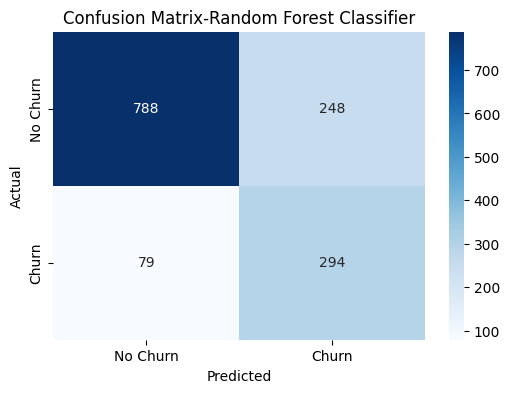


====ROC Curve-Random Forest Classifier====


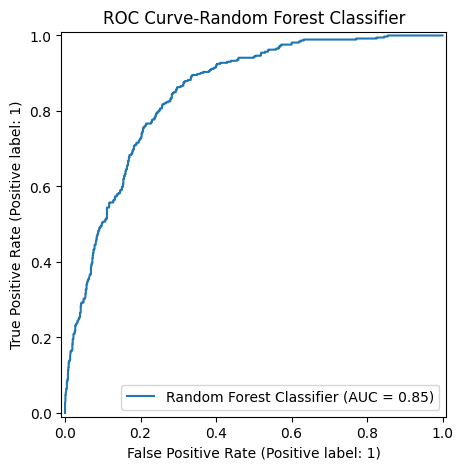

In [ ]:
#training
rfc = RandomForestClassifier(random_state=42,n_estimators=100,max_depth=5)
rfc.fit(X_train_smote,y_train_smote)

#predicting
y_pred=rfc.predict(X_test)
y_prob=rfc.predict_proba(X_test)[:,1]

# Evaluation (prints + stores results)
evaluate_model("Random Forest", y_test, y_pred, y_prob)

#confusion matrix
print("\n"+"="*4+"Confusion Matrix"+"="*4)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm,annot=True,fmt="d",cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix-Random Forest Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print("\n"+"="*4+"ROC Curve-Random Forest Classifier"+"="*4)
#ROC curve
fig,ax=plt.subplots(figsize=(7,5))
RocCurveDisplay.from_estimator(rfc,X_test,
                               y_test,
                               name="Random Forest Classifier",
                               ax=ax)
ax.set_title("ROC Curve-Random Forest Classifier")
plt.show()

KNN Classifiers


====KNN Results====
Accuracy Score:  0.7161
Precision Score: 0.4768
Recall Score:    0.7426
F1 Score:        0.5807
ROC_AUC Score:   0.8100

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.88      0.71      0.79      1036
       Churn       0.48      0.74      0.58       373

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.68      1409
weighted avg       0.78      0.72      0.73      1409


====Confusion Matrix====


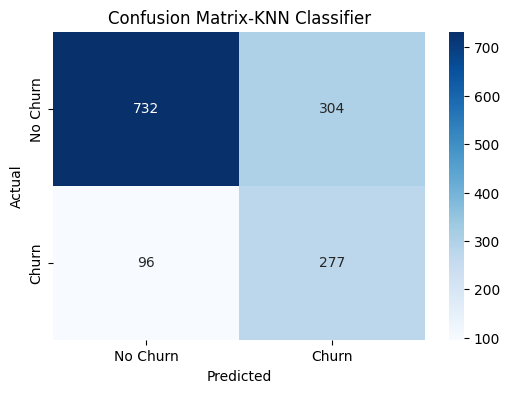


====ROC Curve-KNN Classifier====


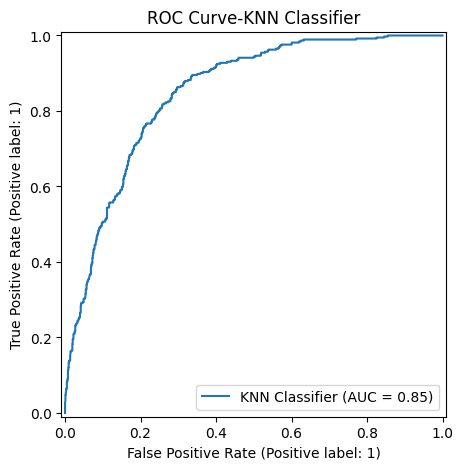

In [ ]:
#training
knn = KNeighborsClassifier(n_neighbors=15,metric="euclidean")
knn.fit(X_train_smote,y_train_smote)

#predicting
y_pred=knn.predict(X_test)
y_prob=knn.predict_proba(X_test)[:,1]

# Evaluation (prints + stores results)
evaluate_model("KNN", y_test, y_pred, y_prob)

#confusion matrix
print("\n"+"="*4+"Confusion Matrix"+"="*4)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm,annot=True,fmt="d",cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix-KNN Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print("\n"+"="*4+"ROC Curve-KNN Classifier"+"="*4)
#ROC curve
fig,ax=plt.subplots(figsize=(7,5))
RocCurveDisplay.from_estimator(rfc,X_test,
                               y_test,
                               name="KNN Classifier",
                               ax=ax)
ax.set_title("ROC Curve-KNN Classifier")
plt.show()

Neural Network


====Neural Network Results====
Accuracy Score:  0.7012
Precision Score: 0.4659
Recall Score:    0.8794
F1 Score:        0.6091
ROC_AUC Score:   0.8404

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.94      0.64      0.76      1036
       Churn       0.47      0.88      0.61       373

    accuracy                           0.70      1409
   macro avg       0.70      0.76      0.68      1409
weighted avg       0.81      0.70      0.72      1409


====Confusion Matrix====


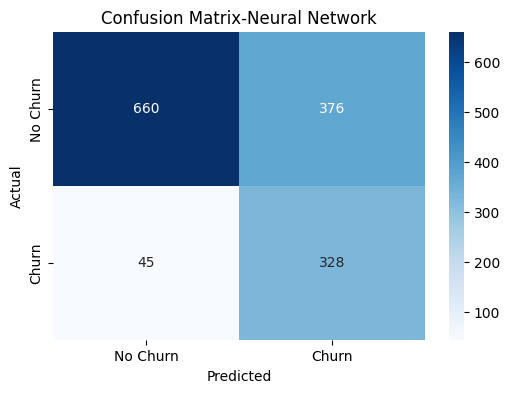


====ROC Curve-Neural Network====


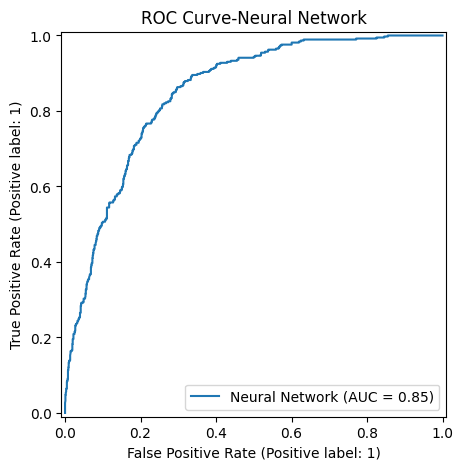

In [ ]:
#training
nn=MLPClassifier(hidden_layer_sizes=(128,64,32),activation="relu",solver="adam",max_iter=5000,random_state=42)
nn.fit(X_train_smote,y_train_smote)

#predicting
y_pred=nn.predict(X_test)
y_prob=nn.predict_proba(X_test)[:,1]

# Evaluation (prints + stores results)
evaluate_model("Neural Network", y_test, y_pred, y_prob)

#confusion matrix
print("\n"+"="*4+"Confusion Matrix"+"="*4)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm,annot=True,fmt="d",cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix-Neural Network")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print("\n"+"="*4+"ROC Curve-Neural Network"+"="*4)
#ROC curve
fig,ax=plt.subplots(figsize=(7,5))
RocCurveDisplay.from_estimator(rfc,X_test,
                               y_test,
                               name="Neural Network",
                               ax=ax)
ax.set_title("ROC Curve-Neural Network")
plt.show()

Deep Neural Network

c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6937 - loss: 0.5980 - val_accuracy: 0.6196 - val_loss: 0.7499
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7201 - loss: 0.5608 - val_accuracy: 0.8279 - val_loss: 0.5091
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7258 - loss: 0.5446 - val_accuracy: 0.7174 - val_loss: 0.6060
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7279 - loss: 0.5408 - val_accuracy: 0.6938 - val_loss: 0.6220
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7332 - loss: 0.5280 - val_accuracy: 0.6383 - val_loss: 0.6299
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7352 - loss: 0.5240 - val_accuracy: 0.7192 - val_loss: 0.5551
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7388 - loss: 0.5264 - val_accuracy: 0.6232 - val_loss: 0.7313
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7434 - loss: 0.5181 - val_accu

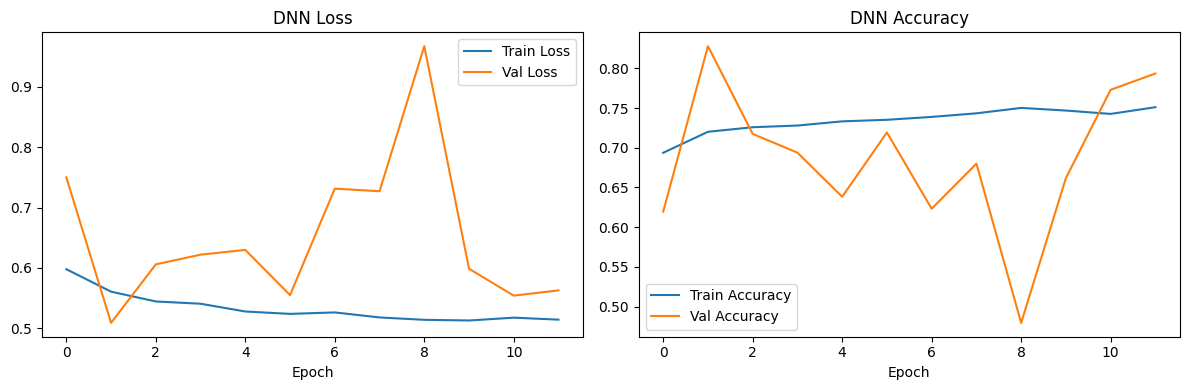

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

====Deep Neural Network Results====
Accuracy Score:  0.7076
Precision Score: 0.4710
Recall Score:    0.8499
F1 Score:        0.6061
ROC_AUC Score:   0.8313

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.92      0.66      0.77      1036
       Churn       0.47      0.85      0.61       373

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.72      1409



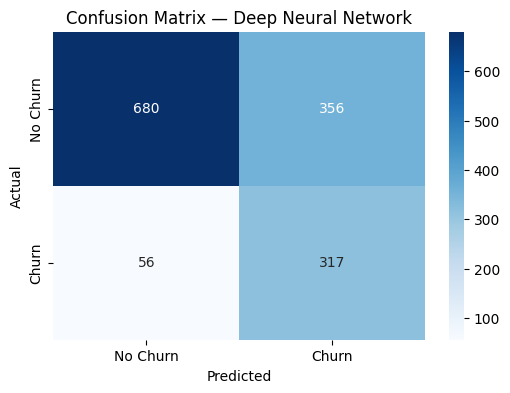

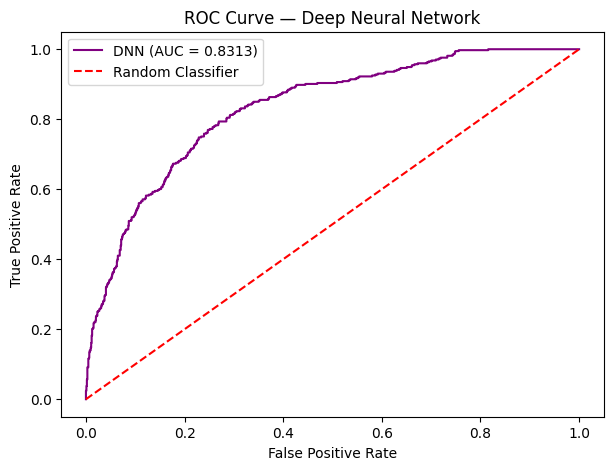

In [ ]:
# Build the DNN
dnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_smote.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

# Compile
dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dnn.summary()

# Early stopping — stops training when val_loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = dnn.fit(
    X_train_smote, y_train_smote,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DNN Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DNN Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# Predict
y_prob_dnn = dnn.predict(X_test).flatten()
y_pred_dnn = (y_prob_dnn >= 0.5).astype(int)

# Evaluation (prints + stores results)
evaluate_model("Deep Neural Network", y_test, y_pred_dnn, y_prob_dnn)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dnn)
plt.figure(figsize=(6, 4))
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix — Deep Neural Network")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dnn)
auc_score = roc_auc_score(y_test, y_prob_dnn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='purple', label=f'DNN (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Deep Neural Network')
plt.legend()
plt.show()

Support Vector Machine (SVM)


====SVM Results====
Accuracy Score:  0.6891
Precision Score: 0.4395
Recall Score:    0.6327
F1 Score:        0.5187
ROC_AUC Score:   0.7574

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.84      0.71      0.77      1036
       Churn       0.44      0.63      0.52       373

    accuracy                           0.69      1409
   macro avg       0.64      0.67      0.64      1409
weighted avg       0.74      0.69      0.70      1409


====Confusion Matrix====


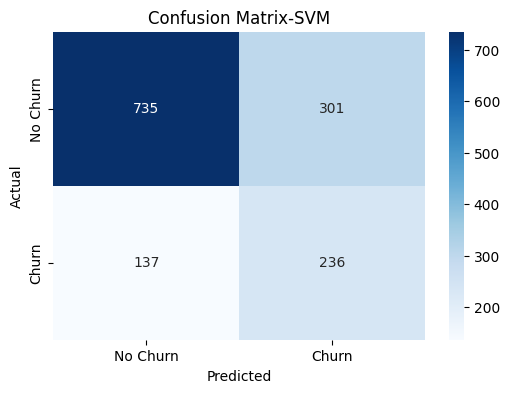


====ROC Curve-SVM====


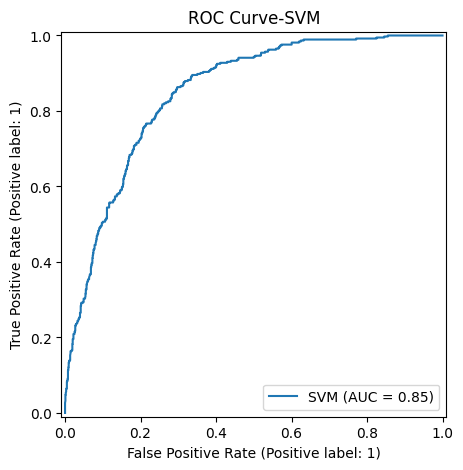

In [ ]:
#training
svm=SVC(probability=True,random_state=42,kernel="rbf")
svm.fit(X_train_smote,y_train_smote)

#predicting
y_pred=svm.predict(X_test)
y_prob=svm.predict_proba(X_test)[:,1]

# Evaluation (prints + stores results)
evaluate_model("SVM", y_test, y_pred, y_prob)

#confusion matrix
print("\n"+"="*4+"Confusion Matrix"+"="*4)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm,annot=True,fmt="d",cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix-SVM")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print("\n"+"="*4+"ROC Curve-SVM"+"="*4)
#ROC curve
fig,ax=plt.subplots(figsize=(7,5))
RocCurveDisplay.from_estimator(rfc,X_test,
                               y_test,
                               name="SVM",
                               ax=ax)
ax.set_title("ROC Curve-SVM")
plt.show()

XGBoost


====XGBooste Results====
Accuracy Score:  0.7885
Precision Score: 0.5979
Recall Score:    0.6139
F1 Score:        0.6058
ROC_AUC Score:   0.8335

====Classification Report====
              precision    recall  f1-score   support

    No Churn       0.86      0.85      0.86      1036
       Churn       0.60      0.61      0.61       373

    accuracy                           0.79      1409
   macro avg       0.73      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409


====Confusion Matrix====


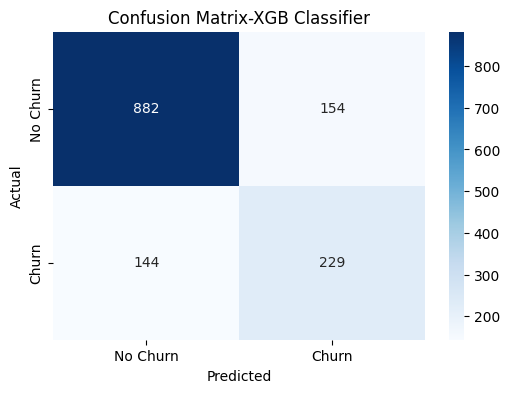


====ROC Curve-XGB Classifier====


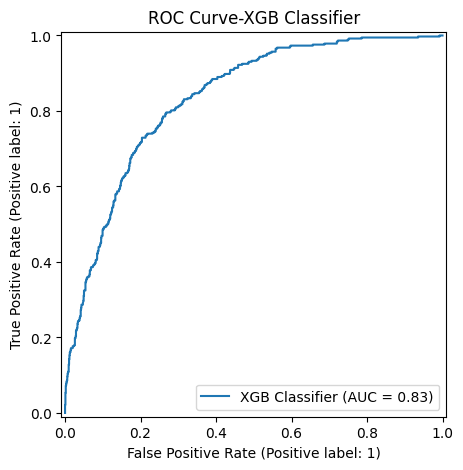

In [ ]:
#training
xgb=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train_smote,y_train_smote)

#predicting
y_pred=xgb.predict(X_test)
y_prob=xgb.predict_proba(X_test)[:,1]

# Evaluation (prints + stores results)
evaluate_model("XGBooste", y_test, y_pred, y_prob)

#confusion matrix
print("\n"+"="*4+"Confusion Matrix"+"="*4)
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm,annot=True,fmt="d",cmap="Blues",
           xticklabels=["No Churn", "Churn"],
           yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix-XGB Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()
print("\n"+"="*4+"ROC Curve-XGB Classifier"+"="*4)
#ROC curve
fig,ax=plt.subplots(figsize=(7,5))
RocCurveDisplay.from_estimator(xgb, X_test, y_test,
                              name="XGB Classifier",
                              ax=ax)
ax.set_title("ROC Curve-XGB Classifier")
plt.show()

Comparison between models

In [ ]:
df_results = pd.DataFrame(results)

print("\n" + "="*4 + "Final Model Comparison" + "="*4)
print(df_results)


====Final Model Comparison====
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.743790   0.510526  0.780161  0.617179  0.844542
1        Random Forest  0.767921   0.542435  0.788204  0.642623  0.848435
2                  KNN  0.716111   0.476764  0.742627  0.580713  0.810014
3       Neural Network  0.701207   0.465909  0.879357  0.609099  0.840357
4  Deep Neural Network  0.707594   0.471025  0.849866  0.606119  0.831326
5                  SVM  0.689141   0.439479  0.632708  0.518681  0.757353
6             XGBooste  0.788502   0.597911  0.613941  0.605820  0.833497


In [ ]:
print("\n" + "="*4 + "Best Model Per Metric" + "="*4)
print(df_results.set_index("Model").idxmax())


====Best Model Per Metric====
Accuracy           XGBooste
Precision          XGBooste
Recall       Neural Network
F1 Score      Random Forest
ROC-AUC       Random Forest
dtype: object


In [ ]:
print("\n" + "="*4 + "Sorted by F1 Score (Best Overall)" + "="*4)
print(df_results.sort_values(by="F1 Score", ascending=False))


====Sorted by F1 Score (Best Overall)====
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
1        Random Forest  0.767921   0.542435  0.788204  0.642623  0.848435
0  Logistic Regression  0.743790   0.510526  0.780161  0.617179  0.844542
3       Neural Network  0.701207   0.465909  0.879357  0.609099  0.840357
4  Deep Neural Network  0.707594   0.471025  0.849866  0.606119  0.831326
6             XGBooste  0.788502   0.597911  0.613941  0.605820  0.833497
2                  KNN  0.716111   0.476764  0.742627  0.580713  0.810014
5                  SVM  0.689141   0.439479  0.632708  0.518681  0.757353


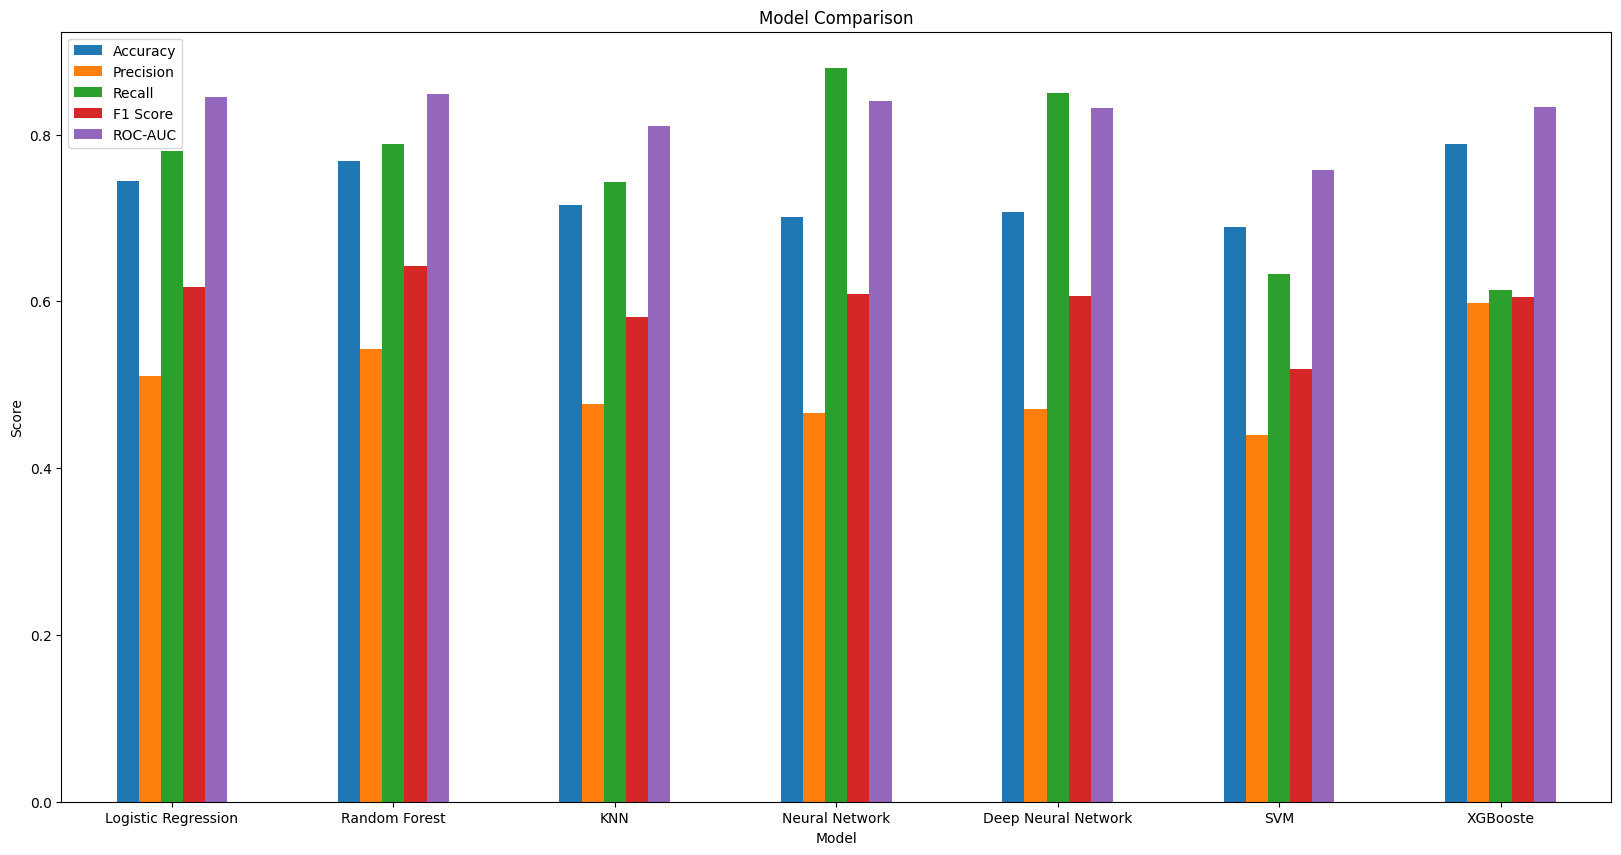

In [ ]:
df_results.set_index("Model").plot(kind="bar", figsize=(20,10))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()